
# van der Waals EOS in Reduced Form: $Z$ vs. Reduced Pressure

This notebook uses the reduced van der Waals equation of state

$$
P_r = \frac{8 T_r}{3 V_r - 1} - \frac{3}{V_r^2}
$$

to compute and plot the compressibility factor $Z$ as a function of reduced pressure $P_r$ for several reduced-temperature isotherms $T_r$.

Using $Z = PV/(RT)$ together with the van der Waals critical relation

$$
Z = \frac{P V}{R T} = \frac{P_r V_r}{T_r}\left(\frac{P_c V_c}{R T_c}\right)
= \frac{3}{8}\frac{P_r V_r}{T_r},
$$

we compute $Z$ once the reduced molar volume $V_r$ is found from the reduced EOS.

For each pair $(P_r, T_r)$, the notebook solves the cubic equation in $V_r$ and selects the **largest real root** greater than $1/3$, corresponding to the gas-like branch.


In [5]:

import numpy as np
import matplotlib.pyplot as plt

# Make plots a bit larger for presentation
plt.rcParams["figure.figsize"] = (9, 6)
plt.rcParams["font.size"] = 12



## Helper functions

Starting from

$$
P_r = \frac{8 T_r}{3 V_r - 1} - \frac{3}{V_r^2},
$$

we rearrange to a cubic polynomial in $V_r$:

$$
3 P_r V_r^3 - (P_r + 8 T_r) V_r^2 + 9 V_r - 3 = 0.
$$

We solve this cubic numerically and keep the largest physically meaningful real root.


In [6]:

def vdw_reduced_cubic_coeffs(Pr, Tr):
    """
    Returns coefficients for the cubic in Vr:
        3*Pr*Vr^3 - (Pr + 8*Tr)*Vr^2 + 9*Vr - 3 = 0
    """
    return [3.0 * Pr, -(Pr + 8.0 * Tr), 9.0, -3.0]


def gas_root_vr(Pr, Tr, tol=1e-10):
    """
    Solve the reduced vdW EOS for Vr at a given (Pr, Tr) and return the
    largest real root greater than 1/3 (gas-like root).
    """
    coeffs = vdw_reduced_cubic_coeffs(Pr, Tr)
    roots = np.roots(coeffs)

    real_roots = np.real(roots[np.isclose(np.imag(roots), 0.0, atol=tol)])
    physical_roots = real_roots[real_roots > (1.0 / 3.0 + tol)]

    if len(physical_roots) == 0:
        return np.nan

    return np.max(physical_roots)


def compressibility_from_reduced(Pr, Tr, Vr):
    """
    Z = PV/(RT) = (3/8) * (Pr*Vr/Tr) for the reduced vdW EOS.
    """
    return (3.0 / 8.0) * (Pr * Vr / Tr)


## Generate $Z$ vs. $P_r$ isotherms

In [7]:

# Choose reduced temperatures for the isotherms
Tr_values = [1.0, 1.1, 1.3, 1.5, 1.8, 2.0]

# Reduced pressure range
Pr_values = np.linspace(0.02, 8.0, 500)

results = {}
for Tr in Tr_values:
    Z_vals = []
    Vr_vals = []
    for Pr in Pr_values:
        Vr = gas_root_vr(Pr, Tr)
        Z = compressibility_from_reduced(Pr, Tr, Vr) if np.isfinite(Vr) else np.nan
        Vr_vals.append(Vr)
        Z_vals.append(Z)

    results[Tr] = {
        "Pr": Pr_values.copy(),
        "Vr": np.array(Vr_vals),
        "Z": np.array(Z_vals),
    }


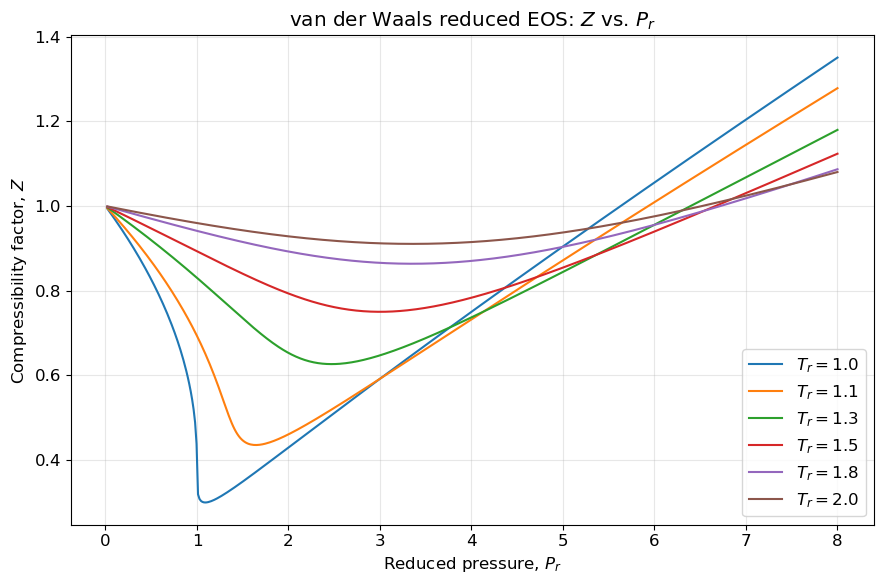

In [8]:

fig, ax = plt.subplots()

for Tr in Tr_values:
    ax.plot(results[Tr]["Pr"], results[Tr]["Z"], label=fr"$T_r = {Tr}$")

ax.set_xlabel(r"Reduced pressure, $P_r$")
ax.set_ylabel(r"Compressibility factor, $Z$")
ax.set_title(r"van der Waals reduced EOS: $Z$ vs. $P_r$")
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()



## Notes

- Below the critical temperature, the cubic may have three real roots over part of the pressure range.
- This notebook chooses the **largest real root**, which corresponds to the gas-like branch.
- If you want, you can modify the root-selection logic to plot the liquid-like branch or all real roots.
